
# Mock Compositional Data + Lin GP Regression 

In [1]:
import sys
from pathlib import Path

project_root = Path(r"c:\Users\floki\PycharmProjects\dash-azure-prototype")
src_root = project_root / "src"
for p in (project_root, src_root):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))
artifact_dir = project_root / "ml" / "models" / "artifacts" / "demo_lin"
artifact_dir.mkdir(parents=True, exist_ok=True)

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold

In [3]:
from ml.scripts.plotting import (
    plot_true_vs_predicted,
)
from ml.scripts.trainers import GPRTrainer
from ml.scripts.log import init_ml_logger, log_data_summary
from worker.models import LIN
from worker.models.specs import ModelConfig, PreprocessConfig, AuxilaryData
from worker.models.io_utils import ArtifactIO
from worker.torch_utils import get_default_device

In [4]:
# load demo data for testing, geology data with compositional features
data_path =  project_root / "ml" / "data" / "examples" / "sediments_data.csv"
df = pd.read_csv(data_path)
df = df.rename(columns=lambda c: str(c).strip())
df = df[[k for k in df.keys() if "X" in k or ("Y" in k and int(k[1:]) <= 10)]]
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,Y1,Y2,Y3,Y4,Y5,Y6,Y7,Y8,Y9,Y10
0,50.878306,1.585700,15.139037,9.430002,0.158689,7.377606,11.991212,2.614107,0.481218,0.222283,...,100.024960,62.401831,0.380,95.000000,2.480362,1.381603,8.698865,64.113000,254.781000,306.508000
1,50.946523,1.538539,15.646498,8.674868,0.167713,7.351243,12.372583,2.601054,0.482049,0.218930,...,100.000000,64.256757,NaN,NaN,2.463131,1.332379,8.022467,69.894193,241.946713,277.496404
2,50.914880,1.529394,15.190011,9.153952,0.157481,7.495558,12.170296,2.544098,0.472642,0.229280,...,99.984392,63.464847,0.347,86.952381,2.438507,1.368964,8.576773,73.000000,280.000000,270.000000
3,51.038205,1.462966,15.420000,9.085860,0.160000,7.583125,12.280000,2.461189,0.417908,0.221035,...,100.265688,63.906136,0.371,102.666667,2.377320,1.335617,8.605845,77.000000,283.000000,277.000000
4,50.612286,1.409480,15.407908,8.916492,0.180880,7.795704,12.386817,2.507115,0.440833,0.209050,...,99.879764,64.970813,NaN,NaN,2.463667,1.348711,8.677588,73.010640,285.408170,271.692840


In [5]:
# train test split
feature_cols = [k for k in df.keys() if "X" in k]
target_cols = [k for k in df.keys() if "Y" in k]

# row_sums = df[feature_cols].sum(axis=1)
# df[feature_cols] = df[feature_cols].div(row_sums.replace(0, pd.NA), axis=0)
df[feature_cols] /= 100

df = df.dropna(subset=feature_cols, how="any", axis=0)
df = df.dropna(subset=target_cols, how="all", axis=0)
df = df.drop_duplicates(subset=feature_cols, keep="first", ignore_index=True)
df = df.reset_index(drop=True)

X = df[feature_cols].to_numpy()
y = df[target_cols].to_numpy()

train_x, test_x, train_y, test_y = train_test_split(
    X, y, test_size=0.1, random_state=1, shuffle=True,
)

train_x_raw = train_x.copy()
test_x_raw = test_x.copy()
train_y_raw = train_y.copy()
test_y_raw = test_y.copy()

In [6]:
# drop features without variance
var_x = VarianceThreshold(threshold=1e-6)
train_x = var_x.fit_transform(train_x)
test_x = var_x.transform(test_x)
train_x_raw = var_x.transform(train_x_raw)
test_x_raw = var_x.transform(test_x_raw)
kept_mask_x = var_x.get_support()
feature_cols = [c for c, keep in zip(feature_cols, kept_mask_x) if keep]

In [7]:
# drop targets without variance
var_y = VarianceThreshold(threshold=1e-6)
train_y = var_y.fit_transform(train_y)
test_y = var_y.transform(test_y)
train_y_raw = var_y.transform(train_y_raw)
test_y_raw = var_y.transform(test_y_raw)
kept_mask_y = var_y.get_support()
target_cols = [c for c, keep in zip(target_cols, kept_mask_y) if keep]

In [8]:
# target scaling
scaler_y = MinMaxScaler()
train_y = scaler_y.fit_transform(train_y)
test_y = scaler_y.transform(test_y)

In [9]:
# setup model
prep = PreprocessConfig(scaler_y=scaler_y)
noise_rank = 1
covar_rank = 1
spec = ModelConfig(
    model_type="lin",
    features=feature_cols,
    targets=target_cols,
    requires_aux=True,
    model_kwargs={"covar_rank": covar_rank, "noise_rank": noise_rank},
)
aux = AuxilaryData(train_x=train_x, train_y=train_y)
model = LIN(spec, prep, aux)

In [10]:
# conduct training
device = get_default_device()
print(f"Running on {str(device)}")
trainer = GPRTrainer(model, device=device, lr=0.05)
metrics = trainer.train(train_x, train_y, epochs=500)

Running on cuda


GP training:   0%|          | 0/500 [00:00<?, ?it/s]

In [11]:
# check if storing / loading of artifacts works
ArtifactIO.save(artifact_dir, model=model, spec=spec, prep=prep, aux=aux)
loaded_model = ArtifactIO.load(artifact_dir, device=device)

In [12]:
# test predictions on test set
preds = loaded_model.predict(test_x_raw, device=device, return_std=True)
pred_mean = preds.get('mean')
pred_std = preds.get('std')

preds_train = loaded_model.predict(train_x_raw, device=device, return_std=True)
pred_mean_train = preds_train.get('mean')
pred_std_train = preds_train.get('std')

In [13]:
logger, _ = init_ml_logger(artifact_dir, "training")
if logger is not None:
    logger.info("Train time (s): %.3f", trainer.duration)
    log_data_summary(
        logger,
        train_y_raw,
        y_pred=pred_mean_train,
        y_std=pred_std_train,
        feature_cols=feature_cols,
        target_cols=target_cols,
        phase="Train",
    )
    log_data_summary(
        logger,
        test_y_raw,
        y_pred=pred_mean,
        y_std=pred_std,
        feature_cols=feature_cols,
        target_cols=target_cols,
        phase="Test",
    )

2026-04-01 20:34:32,603 | INFO | Train time (s): 16.613
2026-04-01 20:34:32,604 | INFO | Train: n_obs=128 n_features=8 n_targets=10 non_nan_targets=785
2026-04-01 20:34:32,604 | INFO | Train metrics per target:
2026-04-01 20:34:32,608 | INFO |   Y1 | R2=0.2537 MAPE=0.0022 PICP(95%)=0.8516
2026-04-01 20:34:32,608 | INFO |   Y2 | R2=0.9943 MAPE=0.0029 PICP(95%)=1.0000
2026-04-01 20:34:32,614 | INFO |   Y3 | R2=0.8865 MAPE=0.0622 PICP(95%)=0.9861
2026-04-01 20:34:32,615 | INFO |   Y4 | R2=0.0325 MAPE=0.3059 PICP(95%)=1.0000
2026-04-01 20:34:32,615 | INFO |   Y5 | R2=0.6922 MAPE=0.0215 PICP(95%)=0.9487
2026-04-01 20:34:32,615 | INFO |   Y6 | R2=0.8650 MAPE=0.0201 PICP(95%)=0.9870
2026-04-01 20:34:32,615 | INFO |   Y7 | R2=0.8340 MAPE=0.0117 PICP(95%)=0.9870
2026-04-01 20:34:32,615 | INFO |   Y8 | R2=0.7583 MAPE=0.1309 PICP(95%)=0.9608
2026-04-01 20:34:32,625 | INFO |   Y9 | R2=0.6547 MAPE=0.2801 PICP(95%)=1.0000
2026-04-01 20:34:32,625 | INFO |   Y10 | R2=0.8749 MAPE=0.0201 PICP(95%)=0.980

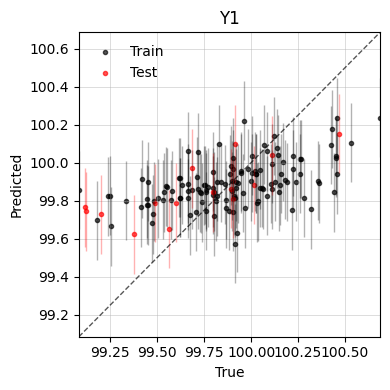

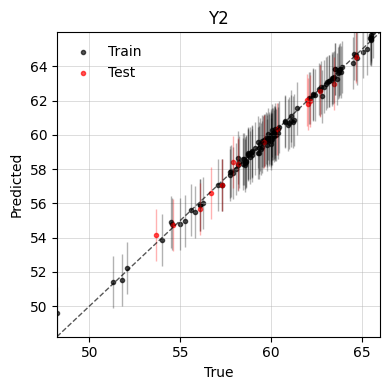

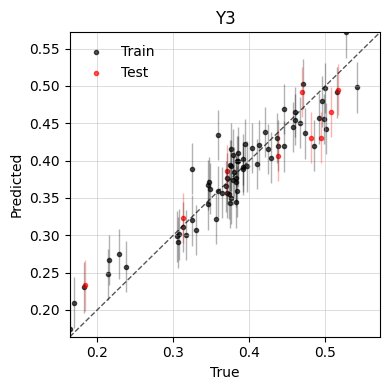

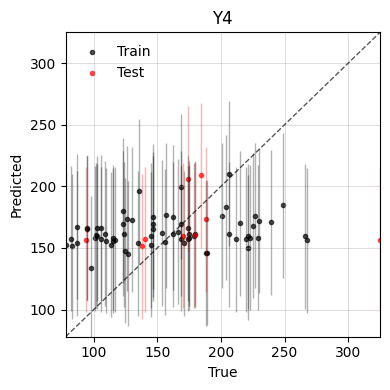

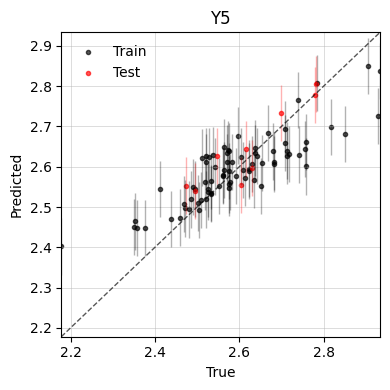

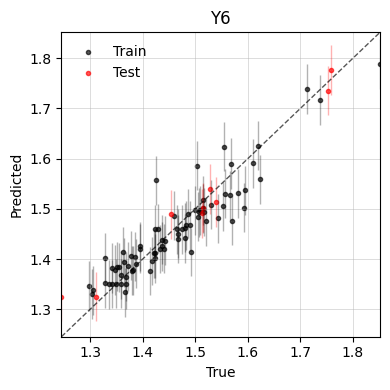

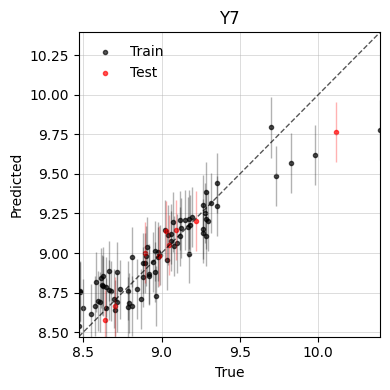

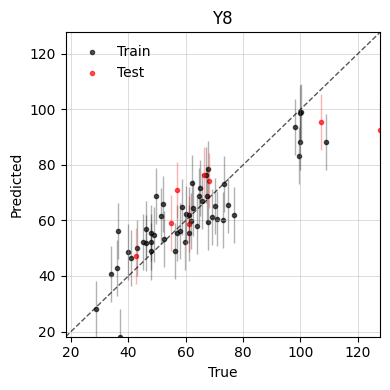

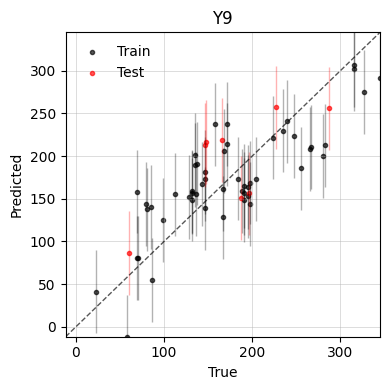

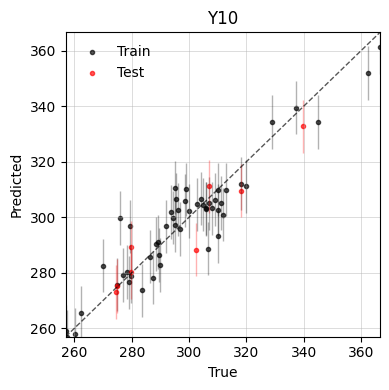

In [14]:
plots_dir = artifact_dir / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)
plot_true_vs_predicted(
    train_y_raw,
    pred_mean_train,
    y_std=pred_std_train,
    y_true_test=test_y_raw,
    y_pred_test=pred_mean,
    y_std_test=pred_std,
    target_cols=target_cols,
    show_std=pred_std is not None or pred_std_train is not None,
    filepath=plots_dir / "results",
)